# Fitting Simple Linear Statistical Models
## Step 3 — Curves and a transformed cost

In the previous week we built a model with two predictors:

$$\text{TotalCost} = \beta_0 + \beta_1\,\text{LOS} + \beta_2\,\text{NumRevCodes} + \varepsilon$$

It explained 68% of the variation in cost, and adding more variables barely helped.

But we only ever tried **straight lines**. In this notebook we ask two new questions:

1. **Do these predictors act in a straight line at all?** Perhaps the tenth service on a bill does not cost the same as the thirtieth.
2. **Are we modelling the right thing?** Cost is always positive and heavily skewed, which a straight line handles poorly.

We still use only **quantitative** predictors. Categories like `TypeFlag` come in the next notebook.

---
## 1. Setup

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["figure.dpi"] = 110

---
## 2. The data

In [15]:
URL = ("https://raw.githubusercontent.com/thousandoaks/Python4DS-I/"
       "main/datasets/HealthcareDataset_PublicRelease.csv")

try:
    events = pd.read_csv("medical_events.csv", parse_dates=["StartDate", "EndDate", "BirthDate"])
    print("loaded medical_events.csv")
except FileNotFoundError:
    print("rebuilding from source")
    lines = pd.read_csv(URL, parse_dates=["StartDate", "EndDate", "BirthDate"])
    lines["LOS"] = (lines.EndDate - lines.StartDate).dt.days
    events = (lines.groupby("MedicalClaim")
              .agg(TotalCost=("TotalExpenses", "sum"),
                   NumRevCodes=("RevenueCode", "nunique"),
                   LOS=("LOS", "first"),
                   TypeFlag=("TypeFlag", "first"))
              .reset_index())

model_step2 = smf.ols("TotalCost ~ LOS + NumRevCodes", data=events).fit()

print(f"{len(events):,} medical events")
print(f"R-squared from Step 2: {model_step2.rsquared:.3f}")

rebuilding from source
3,361 medical events
R-squared from Step 2: 0.681


### 2.1 Two things to notice first

Before fitting anything, check two features of the data that will shape everything we do.

In [16]:
print(f"events lasting 0 days : {(events.LOS == 0).sum():,}  ({(events.LOS == 0).mean():.0%} of all events)")
print(f"cheapest event        : ${events.TotalCost.min():,.0f}")
print(f"most expensive event  : ${events.TotalCost.max():,.0f}")

events lasting 0 days : 1,465  (44% of all events)
cheapest event        : $156
most expensive event  : $1,066,310


**Nearly half of all events last zero days.** These are emergency and outpatient visits that start and finish on the same day. This matters later: $\log(0)$ does not exist, so if we ever take a logarithm of length of stay we must use $\log(\text{LOS}+1)$.

**Costs run from \$156 to over \$1 million, and none are zero.** That enormous range is a warning sign for a straight-line model, and the fact that nothing is zero means we can safely take the logarithm of cost.

---
## 3. Is the relationship really a straight line?

The simplest way to check is to group events by the value of a predictor and plot the **average cost** in each group. If the relationship is a straight line, the averages fall on a line.

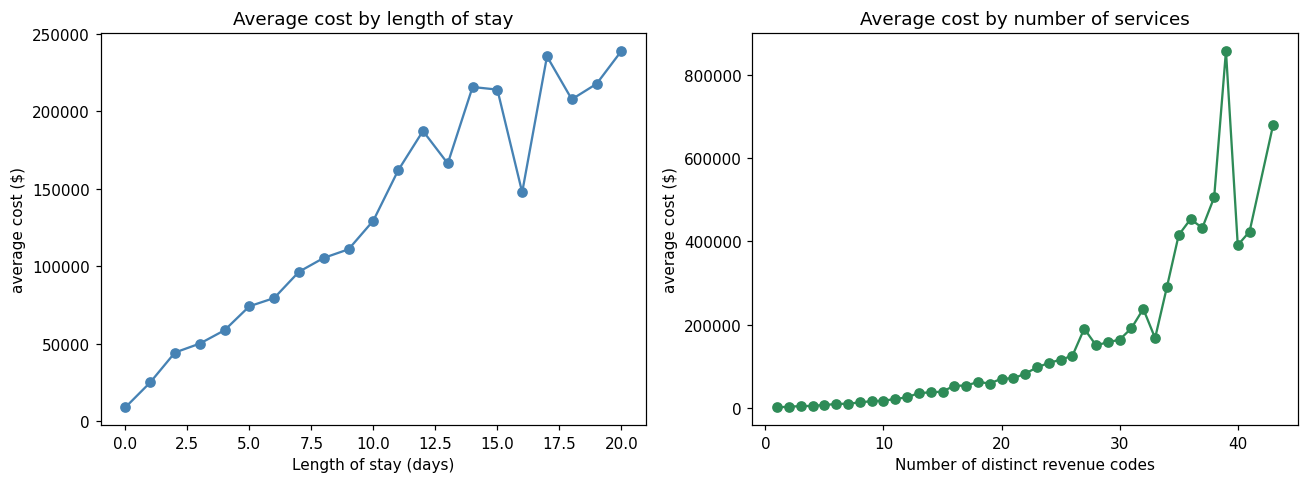

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# average cost at each length of stay (up to 20 days)
los_avg = events[events.LOS <= 20].groupby("LOS").TotalCost.mean()
ax[0].plot(los_avg.index, los_avg.values, "o-", color="steelblue")
ax[0].set(xlabel="Length of stay (days)", ylabel="average cost ($)",
          title="Average cost by length of stay")

# average cost at each number of revenue codes
nrc_avg = events.groupby("NumRevCodes").TotalCost.mean()
ax[1].plot(nrc_avg.index, nrc_avg.values, "o-", color="seagreen")
ax[1].set(xlabel="Number of distinct revenue codes", ylabel="average cost ($)",
          title="Average cost by number of services")

plt.tight_layout(); plt.show()

**Left panel:** cost rises with length of stay in a roughly straight line.

**Right panel:** cost does **not** rise in a straight line with the number of services. The curve is flat at first and then bends steeply upward. Going from 5 to 10 services adds little; going from 30 to 35 adds a great deal.

This is a clinical statement as much as a statistical one. Last week's model assumed every extra service costs the same. The picture says otherwise.

---
## 4. Adding a squared term

To let a model bend, we add the predictor **squared**. The model is still fitted by ordinary least squares — only the list of terms changes.

We try it on both predictors and compare the gain in $R^2$.

In [18]:
model_los2 = smf.ols("TotalCost ~ LOS + I(LOS**2) + NumRevCodes", data=events).fit()
model_nrc2 = smf.ols("TotalCost ~ LOS + NumRevCodes + I(NumRevCodes**2)", data=events).fit()

comparison = pd.DataFrame({
    "model": ["Step 2: straight lines only",
              "add LOS squared",
              "add NumRevCodes squared"],
    "R-squared": [model_step2.rsquared, model_los2.rsquared, model_nrc2.rsquared],
})
comparison["gain over Step 2"] = comparison["R-squared"] - model_step2.rsquared

with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
    display(comparison.set_index("model"))

,R-squared,gain over Step 2
model,,
Step 2: straight lines only,0.6810,0.0000
add LOS squared,0.6814,0.0004
add NumRevCodes squared,0.7339,0.0529


The two squared terms behave completely differently.

- **Squaring `LOS` gains 0.0004** — four ten-thousandths. Nothing. The left-hand plot already told us this: that relationship was already straight.
- **Squaring `NumRevCodes` gains 0.053** — over five percentage points. This is a large improvement, and it came from a variable that was *already in the model*. We collected no new data; we simply let it curve.

For comparison, the five extra variables we tested in Step 2 added about 0.005 between them, all told. **This single squared term is worth ten times all of them.**

We keep `NumRevCodes²` and drop `LOS²`.

In [19]:
model = model_nrc2
print(model.summary().tables[1])
print(f"R-squared: {model.rsquared:.4f}")

                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.555e+04   1674.680      9.284      0.000    1.23e+04    1.88e+04
LOS                  6644.0478    178.337     37.256      0.000    6294.387    6993.708
NumRevCodes         -3160.7908    255.510    -12.371      0.000   -3661.762   -2659.819
I(NumRevCodes ** 2)   227.7414      8.814     25.839      0.000     210.460     245.022
R-squared: 0.7339


### 4.1 How to read a model with a squared term

Look at the coefficient on `NumRevCodes`: it is **negative**, about −\$3,161. Read on its own, that says billing more services *reduces* cost, which is obviously wrong.

The mistake is reading it on its own. Once a variable appears both plain and squared, **the two coefficients only mean something together**. The cost of one more service depends on how many services there already are:

$$\text{cost of one more service} = \beta_{\text{NumRevCodes}} + 2 \times \beta_{\text{NumRevCodes}^2} \times \text{NumRevCodes}$$

So instead of reporting coefficients, we report **what one more service costs at different levels of complexity**.

In [20]:
b1 = model.params["NumRevCodes"]
b2 = model.params["I(NumRevCodes ** 2)"]

levels = [5, 10, 15, 20, 25, 30, 35, 40]
marginal = pd.DataFrame({
    "number of services already billed": levels,
    "cost of one more service ($)": [b1 + 2 * b2 * k for k in levels],
})

with pd.option_context("display.float_format", lambda v: f"{v:,.0f}"):
    display(marginal.set_index("number of services already billed"))

,cost of one more service ($)
number of services already billed,
5,-883
10,"1,394"
15,"3,671"
20,"5,949"
25,"8,226"
30,"10,504"
35,"12,781"
40,"15,059"


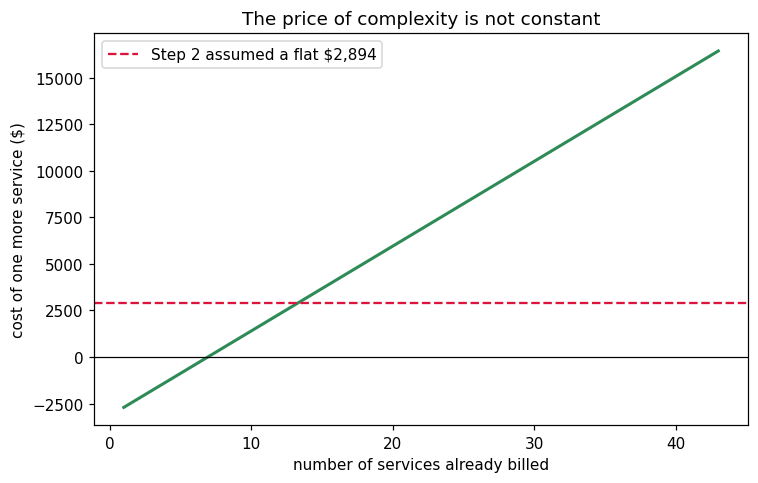

In [21]:
grid = np.arange(1, 44)
plt.plot(grid, b1 + 2 * b2 * grid, color="seagreen", lw=2)
plt.axhline(0, color="black", lw=0.8)
plt.axhline(model_step2.params["NumRevCodes"], color="crimson", ls="--", lw=1.5,
            label=f"Step 2 assumed a flat ${model_step2.params['NumRevCodes']:,.0f}")
plt.xlabel("number of services already billed")
plt.ylabel("cost of one more service ($)")
plt.title("The price of complexity is not constant")
plt.legend()
plt.tight_layout(); plt.show()

**This is the main finding of the notebook.**

For a simple episode, one more service adds very little. For an episode already billing 30 different services, one more adds roughly \$10,500. **Complexity compounds** — each extra type of service costs more than the last, because the thirty-first service on an admission is rarely another routine test. It usually means another specialty, another procedure, another escalation.

Last week's model was forced to charge one flat price of \$2,894 per service across the whole range (the red dashed line). It therefore **overestimated simple cases and underestimated complex ones** — and for a payer, the complex cases are the expensive ones.

*(A note on the left of the chart: the line dips below zero for very simple episodes. Do not read this as "billing more saves money". It reflects that among the simplest events there is very little cost gradient at all, and a curve has to bend somewhere.)*

---
## 5. A problem the squared term did not fix

Adding the curve improved the fit. It did nothing at all for a second, deeper problem.

A residual is what the model got wrong: actual cost minus predicted cost. If the model is sound, residuals should be a shapeless band around zero, equally wide everywhere.

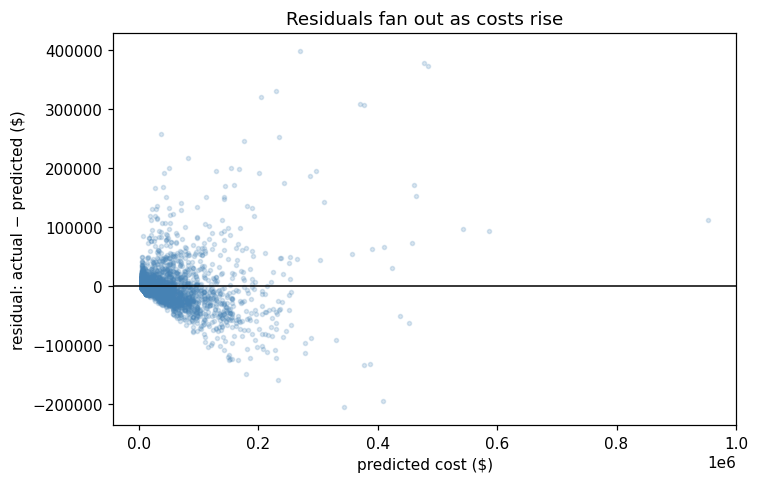

In [22]:
plt.scatter(model.fittedvalues, model.resid, s=7, alpha=0.2, color="steelblue")
plt.axhline(0, color="black", lw=1)
plt.xlabel("predicted cost ($)")
plt.ylabel("residual: actual − predicted ($)")
plt.title("Residuals fan out as costs rise")
plt.tight_layout(); plt.show()

Instead of a band, we get a **funnel**. For cheap events the model is accurate within a few thousand dollars. For expensive events it can be wrong by hundreds of thousands.

**This is not a flaw we can fix with another variable. It is how costs behave.** An event predicted to cost \$800 cannot be wrong by \$40,000. An event predicted to cost \$300,000 easily can. Errors in cost are naturally **proportional** — a percentage of the total — not a fixed number of dollars.

An ordinary regression assumes the opposite: that the typical error is the same size everywhere. Because that assumption is false here, all the standard errors and $p$-values we have reported so far are built on shaky ground.

---
## 6. Modelling cost on a logarithmic scale

If errors are proportional, we should model the **logarithm** of cost rather than cost itself. Working in logs turns "20% more expensive" into a fixed step, which is exactly the kind of effect our data seems to have.

$$\log(\text{TotalCost}) = \beta_0 + \beta_1 \log(\text{LOS}+1) + \beta_2 \log(\text{NumRevCodes}) + \varepsilon$$

We take logs of the predictors too. Note the $+1$ on `LOS`, for the reason we found in Section 2.1: nearly half of all events last zero days.

In [23]:
model_log = smf.ols("np.log(TotalCost) ~ np.log1p(LOS) + np.log(NumRevCodes)",
                    data=events).fit()
print(model_log.summary().tables[1])

                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.9419      0.035    197.461      0.000       6.873       7.011
np.log1p(LOS)           0.4904      0.018     26.511      0.000       0.454       0.527
np.log(NumRevCodes)     1.0906      0.019     56.279      0.000       1.053       1.129


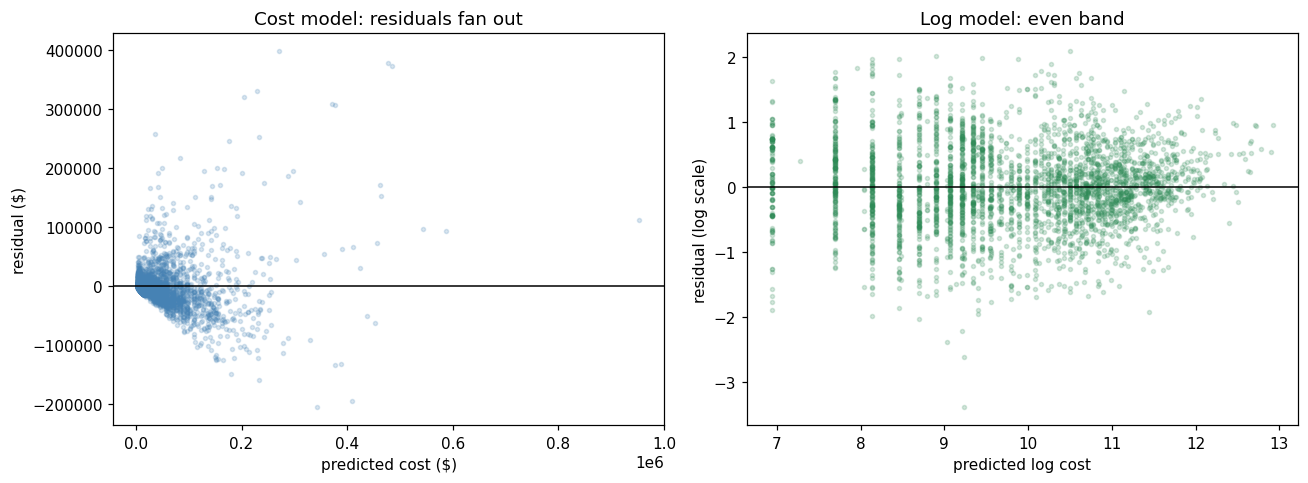

,cost model,log cost model,ideal value
skewness,2.95,-0.06,0
kurtosis,29.12,3.66,3


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].scatter(model.fittedvalues, model.resid, s=7, alpha=0.2, color="steelblue")
ax[0].axhline(0, color="black", lw=1)
ax[0].set(xlabel="predicted cost ($)", ylabel="residual ($)",
          title="Cost model: residuals fan out")

ax[1].scatter(model_log.fittedvalues, model_log.resid, s=7, alpha=0.2, color="seagreen")
ax[1].axhline(0, color="black", lw=1)
ax[1].set(xlabel="predicted log cost", ylabel="residual (log scale)",
          title="Log model: even band")

plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "cost model":     [stats.skew(model.resid),     stats.kurtosis(model.resid, fisher=False)],
    "log cost model": [stats.skew(model_log.resid), stats.kurtosis(model_log.resid, fisher=False)],
    "ideal value":    [0, 3],
}, index=["skewness", "kurtosis"])

with pd.option_context("display.float_format", lambda v: f"{v:.2f}"):
    display(summary)

**The funnel is gone.** The right-hand band is even across the whole range.

The two summary numbers confirm it. Skewness should be near 0 and kurtosis near 3 for well-behaved residuals. The cost model gives 2.95 and 29.1 — far off. The log model gives −0.06 and 3.66 — almost exactly right.

Two notebooks of hunting for extra variables never touched this problem. **One change to the response variable fixed it**, because the problem was never a missing variable. It was that costs are multiplicative and we were modelling them additively.

### 6.1 Reading the log model

In a log model the coefficients become **percentages**, which is often how healthcare costs are discussed anyway.

In [25]:
b_los = model_log.params["np.log1p(LOS)"]
b_nrc = model_log.params["np.log(NumRevCodes)"]

print(f"NumRevCodes coefficient = {b_nrc:.2f}")
print(f"   doubling the number of services multiplies cost by {2**b_nrc:.2f}\n")

print(f"LOS coefficient = {b_los:.2f}")
print(f"   doubling the length of stay multiplies cost by about {2**b_los:.2f}")

NumRevCodes coefficient = 1.09
   doubling the number of services multiplies cost by 2.13

LOS coefficient = 0.49
   doubling the length of stay multiplies cost by about 1.40


**Services: a coefficient of 1.09.** A coefficient of exactly 1 would mean cost rises in step with services — twice the services, twice the cost. At 1.09 cost rises slightly *faster* than that. This is the same finding as Section 4, now in a single number: complexity compounds.

**Length of stay: a coefficient of 0.49.** Doubling the length of stay does **not** double the cost — it multiplies it by about 1.4. This makes clinical sense. The expensive days are at the beginning of an admission: theatre, imaging, intensive monitoring. Later days are largely bed and observation.

Sentences like *"a 10% longer stay costs about 5% more"* are usually easier to act on than *"\$8,267 per day"*.

---
## 7. Summary

| Model | $R^2$ | Outcome |
|---|---|---|
| Step 2: `LOS + NumRevCodes` | 0.681 | starting point |
| add `LOS²` | 0.681 | **rejected** — no gain |
| add `NumRevCodes²` | 0.734 | **kept** — large gain |
| log of cost | *not comparable* | residual problems fixed |

**Four things to take away.**

1. **A variable can be important and still be in the wrong shape.** `NumRevCodes` was already in the model. Letting it curve was worth more than every extra variable we tested last week.
2. **Plot averages before you fit.** The two pictures in Section 3 told us which variable needed a curve and which did not, before we ran anything.
3. **Never read a squared term's coefficients separately.** The plain coefficient went negative and meant nothing alone. Report the cost of one more unit at levels your audience recognises.


### Still to come

- We are still using only **quantitative** predictors. `TypeFlag` separates emergency from inpatient events, and since half our events last zero days, we are almost certainly forcing **two different populations** through one equation.
- We are judging every model on the same data used to fit it, so all these $R^2$ values are optimistic.
- Our 3,361 events come from only 1,757 patients, so the rows are not fully independent.

**Next step:** categorical predictors, starting with `TypeFlag`.